# 🎙️ Deepfake Audio Detector — **CRNN (CNN + BiLSTM)**

Real (human) vs Fake (AI-generated) speech.

This is the CRNN version: the MFCC features, training loop, evaluation, and the `app.py` / `predict.py` interface are **identical** to the CNN baseline — only the model architecture changed (a BiLSTM now models temporal structure across MFCC frames).

**Runtime → Change runtime type → GPU** before running (the BiLSTM trains much faster on GPU).

In [1]:
!pip install librosa scikit-learn tensorflow kaggle streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.0 MB/s eta 0:00:00


## 1 · Mount Drive & create folders

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = '/content/drive/MyDrive/deepfake-audio'
os.makedirs(f'{base}/models', exist_ok=True)
os.makedirs(f'{base}/report', exist_ok=True)

print("✅ Drive mounted & folders ready")

Mounted at /content/drive
✅ Drive mounted & folders ready


## 2 · Download the Fake-or-Real dataset (Kaggle)
Upload your `kaggle.json` when prompted.

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading dataset... (17GB hai, 10-15 min lagenge)")
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -p /content/dataset
print("✅ Download complete!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [12:44<00:00, 22.5MB/s]

✅ Download complete!


In [5]:
print("Unzipping... (2-3 min lagenge)")
!unzip -q /content/dataset/the-fake-or-real-dataset.zip -d /content/dataset/
print("✅ Unzip complete!")

# Dekho kya folders bane
!ls /content/dataset/

Unzipping... (2-3 min lagenge)
✅ Unzip complete!
for-2sec  for-norm  for-original  for-rerec  the-fake-or-real-dataset.zip


In [6]:
# Quick sanity check on the dataset folder layout
!ls /content/dataset/for-norm/
!ls /content/dataset/for-norm/for-norm/
!ls /content/dataset/for-norm/for-norm/training/


for-norm
testing  training  validation
fake  real


## 3 · Count files per split

In [7]:
import os

train_real = '/content/dataset/for-norm/for-norm/training/real'
train_fake = '/content/dataset/for-norm/for-norm/training/fake'
val_real   = '/content/dataset/for-norm/for-norm/validation/real'
val_fake   = '/content/dataset/for-norm/for-norm/validation/fake'
test_real  = '/content/dataset/for-norm/for-norm/testing/real'
test_fake  = '/content/dataset/for-norm/for-norm/testing/fake'

print(f"Training  - Real: {len(os.listdir(train_real))}, Fake: {len(os.listdir(train_fake))}")
print(f"Validation- Real: {len(os.listdir(val_real))},  Fake: {len(os.listdir(val_fake))}")
print(f"Testing   - Real: {len(os.listdir(test_real))}, Fake: {len(os.listdir(test_fake))}")

Training  - Real: 26941, Fake: 26927
Validation- Real: 5400,  Fake: 5398
Testing   - Real: 2264, Fake: 2370


## 4 · Feature extraction — MFCC (40 × 200)
Audio → 16 kHz, 4 s → 40 MFCC coefficients × 200 frames. *(Slow: ~20–30 min.)*

In [8]:
import numpy as np
import librosa
import os
from tqdm import tqdm

def extract_mfcc(file_path, max_len=200, n_mfcc=40):
    try:
        audio, sr = librosa.load(file_path, sr=16000, duration=4.0)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_len:
            mfcc = np.pad(mfcc, ((0,0),(0, max_len - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :max_len]
        return mfcc
    except:
        return None

def load_data(real_path, fake_path):
    X, y = [], []
    for f in tqdm(os.listdir(real_path), desc="Real"):
        feat = extract_mfcc(os.path.join(real_path, f))
        if feat is not None:
            X.append(feat)
            y.append(0)
    for f in tqdm(os.listdir(fake_path), desc="Fake"):
        feat = extract_mfcc(os.path.join(fake_path, f))
        if feat is not None:
            X.append(feat)
            y.append(1)
    return np.array(X), np.array(y)

print("Training data extract ho rahi hai... (20-30 min lagenge)")
X_train, y_train = load_data(train_real, train_fake)
print(f"✅ Train: {X_train.shape}")

print("Validation data...")
X_val, y_val = load_data(val_real, val_fake)
print(f"✅ Val: {X_val.shape}")

print("Testing data...")
X_test, y_test = load_data(test_real, test_fake)
print(f"✅ Test: {X_test.shape}")

Training data extract ho rahi hai... (20-30 min lagenge)


Real:  24%|██▍       | 6502/26941 [01:40<04:12, 80.99it/s] /usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
Real:  97%|█████████▋| 26152/26941 [05:22<00:06, 122.32it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
Fake:  99%|█████████▉| 26757/26927 [04:02<00:01, 149.62it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
Fake: 100%|██████████| 26927/26927 [04:04<00:00, 109.96it/s]


✅ Train: (53868, 40, 200)
Validation data...


Real:  88%|████████▊ | 4777/5400 [00:54<00:05, 116.57it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(
Fake: 100%|██████████| 5398/5398 [00:48<00:00, 112.28it/s]


✅ Val: (10798, 40, 200)
Testing data...


Fake: 100%|██████████| 2370/2370 [00:20<00:00, 115.96it/s]

✅ Test: (4634, 40, 200)


In [9]:
base = '/content/drive/MyDrive/deepfake-audio'

np.save(f'{base}/models/X_train.npy', X_train)
np.save(f'{base}/models/y_train.npy', y_train)
np.save(f'{base}/models/X_val.npy',   X_val)
np.save(f'{base}/models/y_val.npy',   y_val)
np.save(f'{base}/models/X_test.npy',  X_test)
np.save(f'{base}/models/y_test.npy',  y_test)

print("✅ Sab features Drive mein save ho gaye!")

✅ Sab features Drive mein save ho gaye!


## 5 · Model — CRNN (CNN front-end + BiLSTM)
The three Conv blocks extract local time-frequency patterns and shrink the map to `(freq=5, time=25, ch=128)`. We then make **time** the sequence axis and feed the 25-step sequence (640 features/step) to two **Bidirectional LSTM** layers, which capture how the signal evolves over time — the cue that often separates synthetic speech from real.

Input `(40, 200, 1)` and the sigmoid output are unchanged, so your existing `app.py` / `predict.py` keep working without edits.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# ---- add channel dim for the CNN front-end ----
X_train_cnn = X_train[..., np.newaxis]   # (N, 40, 200, 1)
X_val_cnn   = X_val[..., np.newaxis]
X_test_cnn  = X_test[..., np.newaxis]

# ---- feature-map geometry after the CNN front-end ----
N_MFCC, MAX_LEN = 40, 200                 # MUST match extract_mfcc()
# three MaxPooling2D((2,2)) layers -> each axis divided by 8
# (valid padding; exact for 40 and 200). If you change n_mfcc/max_len,
# update these two numbers or the Reshape below will mismatch.
F = N_MFCC // 8     # freq bins left  -> 5
T = MAX_LEN // 8    # time steps left -> 25
C = 128             # channels from the last Conv2D

# ===================== CRNN: CNN feature extractor + BiLSTM =====================
model = models.Sequential([
    layers.Input(shape=(N_MFCC, MAX_LEN, 1)),      # (freq=40, time=200, 1)

    # ---- Convolutional front-end: local time-frequency patterns ----
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),                   # -> (20, 100, 32)
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),                   # -> (10, 50, 64)
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),                   # -> (5, 25, 128)
    layers.Dropout(0.30),

    # ---- Bridge: turn the (freq, time, channels) map into a TIME sequence ----
    layers.Permute((2, 1, 3)),                     # -> (time=T, freq=F, channels=C)
    layers.Reshape((T, F * C)),                    # -> (time=25, features=640)

    # ---- Recurrent back-end: temporal dynamics across frames ----
    # default LSTM settings keep the fast cuDNN GPU kernel (don't add recurrent_dropout)
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Dropout(0.30),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.40),

    # ---- Classifier head ----
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.30),
    layers.Dense(1, activation='sigmoid')          # 0 = Real, 1 = Fake
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 200, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 200, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 100, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 100, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 100, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 25, 5, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 640)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 25, 256)        │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,697 (4.02 MB)

 Trainable params: 1,053,249 (4.02 MB)

 Non-trainable params: 448 (1.75 KB)

## 6 · Train
`ModelCheckpoint` saves the best model to Drive. Same 20-epoch setup as the baseline.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        '/content/drive/MyDrive/deepfake-audio/models/best_model.h5',
        save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=64,
    callbacks=callbacks
)

print("✅ Training complete!")

Epoch 1/20
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9209 - loss: 0.1935
Epoch 1: val_loss improved from None to 0.04860, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 61s 57ms/step - accuracy: 0.9621 - loss: 0.1029 - val_accuracy: 0.9815 - val_loss: 0.0486
Epoch 2/20
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9881 - loss: 0.0368
Epoch 2: val_loss improved from 0.04860 to 0.01194, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9899 - loss: 0.0311 - val_accuracy: 0.9955 - val_loss: 0.0119
Epoch 3/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9938 - loss: 0.0191
Epoch 3: val_loss did not improve from 0.01194
842/842 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9939 - loss: 0.0187 - val_accuracy: 0.9956 - val_loss: 0.0124
Epoch 4/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9941 - loss: 0.0177
Epoch 4: val_loss did not improve from 0.01194
842/842 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 0.9951 - val_loss: 0.0174
Epoch 5/20
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9950 - loss: 0.0158
Epoch 5: val_loss improved from 0.01194 to 0.01193, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9958 - loss: 0.0137 - val_accuracy: 0.9957 - val_loss: 0.0119
Epoch 6/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9961 - loss: 0.0115
Epoch 6: val_loss improved from 0.01193 to 0.00899, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9965 - loss: 0.0115 - val_accuracy: 0.9965 - val_loss: 0.0090
Epoch 7/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9972 - loss: 0.0095
Epoch 7: val_loss improved from 0.00899 to 0.00732, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9967 - loss: 0.0108 - val_accuracy: 0.9979 - val_loss: 0.0073
Epoch 8/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9977 - loss: 0.0080
Epoch 8: val_loss improved from 0.00732 to 0.00561, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9981 - val_loss: 0.0056
Epoch 9/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9972 - loss: 0.0096
Epoch 9: val_loss did not improve from 0.00561
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9910 - val_loss: 0.0273
Epoch 10/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9972 - loss: 0.0083
Epoch 10: val_loss improved from 0.00561 to 0.00333, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9974 - loss: 0.0086 - val_accuracy: 0.9992 - val_loss: 0.0033
Epoch 11/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9979 - loss: 0.0074
Epoch 11: val_loss did not improve from 0.00333
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9978 - loss: 0.0081 - val_accuracy: 0.9973 - val_loss: 0.0076
Epoch 12/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9975 - loss: 0.0085
Epoch 12: val_loss did not improve from 0.00333
842/842 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9978 - loss: 0.0073 - val_accuracy: 0.9981 - val_loss: 0.0072
Epoch 13/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9986 - loss: 0.0042
Epoch 13: val_loss improved from 0.00333 to 0.00255, saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5



Epoch 13: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9992 - val_loss: 0.0026
Epoch 14/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9982 - loss: 0.0062
Epoch 14: val_loss did not improve from 0.00255
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9981 - loss: 0.0063 - val_accuracy: 0.9973 - val_loss: 0.0068
Epoch 15/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9988 - loss: 0.0040
Epoch 15: val_loss did not improve from 0.00255
842/842 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9989 - val_loss: 0.0045
Epoch 16/20
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9983 - loss: 0.0053
Epoch 16: val_loss did not improve from 0.00255
842/842 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9991 - val_loss: 0.0041
Epoch 17/20
841/842 ━


Epoch 18: finished saving model to /content/drive/MyDrive/deepfake-audio/models/best_model.h5
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9991 - val_loss: 0.0021
Epoch 19/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9982 - loss: 0.0061
Epoch 19: val_loss did not improve from 0.00211
842/842 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9984 - loss: 0.0052 - val_accuracy: 0.9989 - val_loss: 0.0050
Epoch 20/20
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9987 - loss: 0.0043
Epoch 20: val_loss did not improve from 0.00211
842/842 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9988 - loss: 0.0043 - val_accuracy: 0.9992 - val_loss: 0.0031
Restoring model weights from the end of the best epoch: 18.
✅ Training complete!


## 7 · Evaluate — Accuracy / F1 / EER + confusion matrix

145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
✅ Accuracy : 97.89%
✅ F1 Score : 97.89%

Classification Report:
              precision    recall  f1-score   support

        Real       0.96      1.00      0.98      2264
        Fake       1.00      0.96      0.98      2370

    accuracy                           0.98      4634
   macro avg       0.98      0.98      0.98      4634
weighted avg       0.98      0.98      0.98      4634

✅ EER      : 1.47%


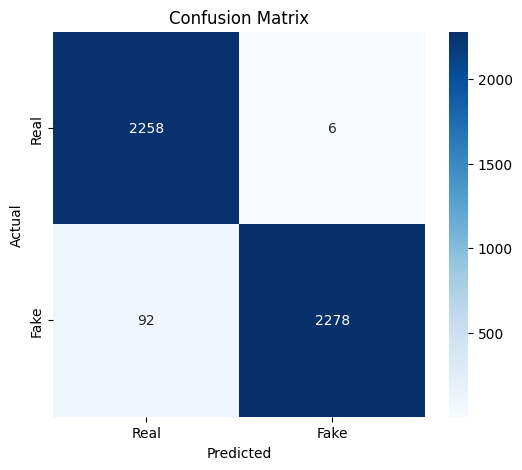

✅ Confusion matrix saved!


In [12]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"✅ Accuracy : {acc*100:.2f}%")
print(f"✅ F1 Score : {f1*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

# EER calculate
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
print(f"✅ EER      : {eer*100:.2f}%")

# Confusion Matrix plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real','Fake'],
            yticklabels=['Real','Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/drive/MyDrive/deepfake-audio/report/confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved!")

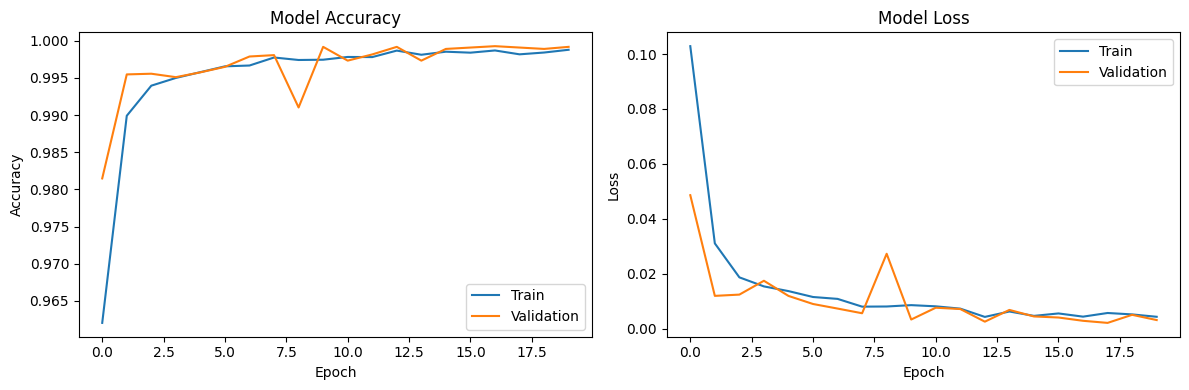

✅ Training plot saved!


In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake-audio/report/training_history.png')
plt.show()
print("✅ Training plot saved!")

## 8 · Export `predict.py` & `app.py`
`app.py` is auto-filled with your **measured CRNN** metrics. Run the evaluation cell above first.

In [14]:
# predict.py works as-is: the CRNN has the SAME input (40,200,1) and sigmoid output.
predict_code = '''
import numpy as np
import librosa
import tensorflow as tf
import sys

# Model load karo
model = tf.keras.models.load_model('best_model.h5')

def predict_audio(file_path):
    audio, sr = librosa.load(file_path, sr=16000, duration=4.0)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    if mfcc.shape[1] < 200:
        mfcc = np.pad(mfcc, ((0,0),(0, 200 - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :200]

    mfcc = mfcc[np.newaxis, ..., np.newaxis]
    prob = model.predict(mfcc)[0][0]

    label = "FAKE (AI Generated)" if prob > 0.5 else "REAL (Human)"
    confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100

    print(f"Result     : {label}")
    print(f"Confidence : {confidence:.2f}%")

if __name__ == "__main__":
    file_path = sys.argv[1]
    predict_audio(file_path)
'''
with open('predict.py','w') as f:
    f.write(predict_code)
print('✅ predict.py written')


✅ predict.py written


In [15]:
# Writes app.py and injects YOUR measured CRNN metrics (run the evaluation cell first).
acc_pct = f'{acc*100:.2f}%'
f1_pct  = f'{f1*100:.2f}%'
eer_pct = f'{eer*100:.2f}%'

app_template = '''
import streamlit as st
import numpy as np
import librosa
import tensorflow as tf
import tempfile
import os
import base64

st.set_page_config(page_title="Deepfake Audio Detector", page_icon="🎙️", layout="centered")

st.markdown("""
<style>
    .title {
        text-align: center;
        font-size: 3em;
        font-weight: bold;
        background: linear-gradient(90deg, #00f2fe, #4facfe);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
    }
    .subtitle { text-align: center; color: #888; font-size: 1.1em; margin-bottom: 2em; }
    .result-fake {
        background: linear-gradient(135deg, #ff416c, #ff4b2b);
        padding: 20px; border-radius: 15px; text-align: center;
        font-size: 1.8em; font-weight: bold; color: white; margin: 20px 0;
    }
    .result-real {
        background: linear-gradient(135deg, #11998e, #38ef7d);
        padding: 20px; border-radius: 15px; text-align: center;
        font-size: 1.8em; font-weight: bold; color: white; margin: 20px 0;
    }
    .record-btn {
        background: linear-gradient(135deg, #f093fb, #f5576c);
        color: white; border: none; padding: 15px 40px;
        border-radius: 50px; font-size: 1.2em;
        cursor: pointer; margin: 10px;
        transition: all 0.3s;
    }
    .stop-btn {
        background: linear-gradient(135deg, #4facfe, #00f2fe);
        color: white; border: none; padding: 15px 40px;
        border-radius: 50px; font-size: 1.2em;
        cursor: pointer; margin: 10px;
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<p class="title">🎙️ Deepfake Audio Detector</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Detect if audio is Real (Human) or Fake (AI Generated)</p>', unsafe_allow_html=True)

col1, col2, col3, col4 = st.columns(4)
col1.metric("Accuracy", "__ACC__")
col2.metric("F1 Score", "__F1__")
col3.metric("EER", "__EER__")
col4.metric("Model", "CRNN")

st.divider()

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("best_model.h5")

model = load_model()

def predict(file_path):
    audio, sr = librosa.load(file_path, sr=16000, duration=4.0)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    if mfcc.shape[1] < 200:
        mfcc = np.pad(mfcc, ((0,0),(0, 200 - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :200]
    mfcc = mfcc[np.newaxis, ..., np.newaxis]
    prob = model.predict(mfcc, verbose=0)[0][0]
    return prob

def show_result(prob):
    if prob > 0.5:
        confidence = prob * 100
        st.markdown('<div class="result-fake">🚨 FAKE — AI Generated</div>', unsafe_allow_html=True)
    else:
        confidence = (1 - prob) * 100
        st.markdown('<div class="result-real">✅ REAL — Human Voice</div>', unsafe_allow_html=True)
    c1, c2 = st.columns(2)
    c1.metric("Confidence", f"{confidence:.2f}%")
    c2.metric("Fake Probability", f"{prob*100:.2f}%")
    st.progress(float(prob))

tab1, tab2 = st.tabs(["📁 Upload Audio", "🎙️ Live Record"])

with tab1:
    st.markdown("### Upload an audio file")
    uploaded_file = st.file_uploader("WAV, MP3, FLAC supported", type=["wav","mp3","flac"])
    if uploaded_file:
        st.audio(uploaded_file)
        with tempfile.NamedTemporaryFile(delete=False, suffix=".wav") as tmp:
            tmp.write(uploaded_file.read())
            tmp_path = tmp.name
        with st.spinner("🔍 Analyzing..."):
            prob = predict(tmp_path)
        os.unlink(tmp_path)
        show_result(prob)

with tab2:
    st.markdown("### Record directly from browser 🎙️")

    # HTML5 Recording Component
    recorder_html = """
    <div style="text-align:center; padding: 20px;">
        <div id="status" style="color:#888; margin-bottom:15px; font-size:1.1em;">
            Click Start to begin recording
        </div>
        <button class="record-btn" onclick="startRecording()" id="startBtn"
            style="background: linear-gradient(135deg, #f093fb, #f5576c);
            color:white; border:none; padding:15px 40px; border-radius:50px;
            font-size:1.1em; cursor:pointer; margin:5px;">
            🎙️ Start Recording
        </button>
        <button onclick="stopRecording()" id="stopBtn" disabled
            style="background: linear-gradient(135deg, #4facfe, #00f2fe);
            color:white; border:none; padding:15px 40px; border-radius:50px;
            font-size:1.1em; cursor:pointer; margin:5px; opacity:0.5;">
            ⏹️ Stop Recording
        </button>
        <br><br>
        <audio id="audioPlayback" controls style="display:none; width:100%; margin:10px 0;"></audio>
        <br>
        <a id="downloadLink" style="display:none;">
            <button style="background: linear-gradient(135deg, #11998e, #38ef7d);
                color:white; border:none; padding:12px 30px; border-radius:50px;
                font-size:1em; cursor:pointer; margin:5px;">
                ⬇️ Download Recording
            </button>
        </a>
    </div>

    <script>
    let mediaRecorder;
    let audioChunks = [];

    async function startRecording() {
        audioChunks = [];
        const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
        mediaRecorder = new MediaRecorder(stream);

        mediaRecorder.ondataavailable = e => audioChunks.push(e.data);
        mediaRecorder.onstop = () => {
            const blob = new Blob(audioChunks, { type: "audio/wav" });
            const url = URL.createObjectURL(blob);

            document.getElementById("audioPlayback").src = url;
            document.getElementById("audioPlayback").style.display = "block";

            const link = document.getElementById("downloadLink");
            link.href = url;
            link.download = "recorded_audio.wav";
            link.style.display = "inline";

            document.getElementById("status").innerHTML =
                "✅ Recording complete! Download the file and upload it above in Tab 1";
            document.getElementById("status").style.color = "#38ef7d";
        };

        mediaRecorder.start();
        document.getElementById("status").innerHTML = "🔴 Recording... Speak now!";
        document.getElementById("status").style.color = "#ff4b2b";
        document.getElementById("startBtn").disabled = true;
        document.getElementById("startBtn").style.opacity = "0.5";
        document.getElementById("stopBtn").disabled = false;
        document.getElementById("stopBtn").style.opacity = "1";
    }

    function stopRecording() {
        mediaRecorder.stop();
        document.getElementById("startBtn").disabled = false;
        document.getElementById("startBtn").style.opacity = "1";
        document.getElementById("stopBtn").disabled = true;
        document.getElementById("stopBtn").style.opacity = "0.5";
    }
    </script>
    """

    st.components.v1.html(recorder_html, height=300)

    st.info("👆 Record karo → Download karo → Upload Tab mein analyze karo!")

    recorded = st.file_uploader("Upload your recorded file here",
                                 type=["wav","mp3","flac"], key="rec")
    if recorded:
        st.audio(recorded)
        with tempfile.NamedTemporaryFile(delete=False, suffix=".wav") as tmp:
            tmp.write(recorded.read())
            tmp_path = tmp.name
        with st.spinner("🔍 Analyzing..."):
            prob = predict(tmp_path)
        os.unlink(tmp_path)
        show_result(prob)
'''

app_code = (app_template
            .replace('__ACC__', acc_pct)
            .replace('__F1__',  f1_pct)
            .replace('__EER__', eer_pct))

with open('app.py','w') as f:
    f.write(app_code)
print('✅ app.py written with CRNN metrics:', acc_pct, '|', f1_pct, '|', eer_pct)


✅ app.py written with CRNN metrics: 97.89% | 97.89% | 1.47%


## 9 · (Optional) Launch the web app via ngrok

In [16]:
# (Optional) Serve the Streamlit app and get a public URL.
!pip install pyngrok -q
from pyngrok import ngrok
import subprocess, time

# 🔒 Paste YOUR token: https://dashboard.ngrok.com/get-started/your-authtoken
# Never commit a real token to GitHub.
NGROK_AUTHTOKEN = "YOUR_NGROK_AUTHTOKEN"
!ngrok authtoken $NGROK_AUTHTOKEN

# make sure the trained model sits next to app.py
!cp /content/drive/MyDrive/deepfake-audio/models/best_model.h5 /content/best_model.h5

ngrok.kill()
public_url = ngrok.connect(8501)
print("🌍 App is live at:", public_url)

subprocess.Popen(["streamlit", "run", "app.py",
                  "--server.port", "8501", "--server.headless", "true"])
time.sleep(5)
print("✅ Streamlit started — open the URL above")


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


ERROR:pyngrok.process.ngrok:t=2026-06-15T13:15:00+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified is an ngrok v1 authtoken, but you're using ngrok v2.\nYour authtoken: YOUR_NGROK_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_106\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-15T13:15:00+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified is an ngrok v1 authtoken, but you're using ngrok v2.\nYour authtoken: YOUR_NGROK_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_106\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified is an ngrok v1 authtoken, but you're using ngrok v2.\nYour authtoken: YOUR_NGROK_AUTHTOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_106\r\n.

---
### After training — update your repo
- Replace the **Results** table in `README.md` with your CRNN numbers (the notebook prints them).
- The CNN→CRNN swap is the only model change; everything else in your pipeline is the same.
- 🔒 Rotate the ngrok token that was committed in your old notebook.